In [29]:
import matplotlib.pyplot as plt   # exibição de imagens e gráficos
import cv2                        # OpenCV: leitura e conversão de imagens
import numpy as np                # operações numéricas com arrays
import time                       # medição do tempo de execução

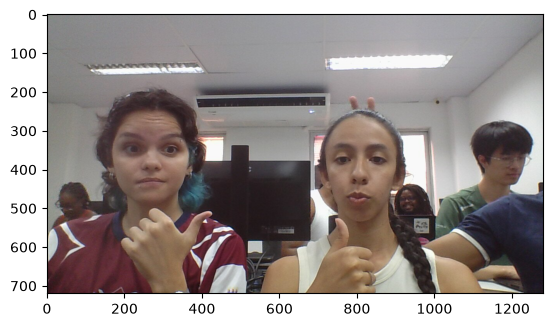

In [30]:
init = time.time()                # marca o instante inicial (em segundos desde 1970)

img = cv2.imread("foto.jpeg")     # lê a imagem do disco -> array (altura, largura, 3)
                                  # ATENÇÃO: o OpenCV lê em BGR, não em RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # converte BGR -> RGB para o matplotlib
                                            # mostrar as cores corretamente

plt.imshow(img)                   # desenha a imagem na figura atual
plt.show()                        # exibe a figura e ESVAZIA a figura atual

In [31]:
n, m, c = img.shape               # desempacota as dimensões:
                                  #   n = linhas (altura em pixels)
                                  #   m = colunas (largura em pixels)
                                  #   c = canais de cor (3 = R, G, B)
print(f"linhas: {n}, colunas: {m}, cores: {c}")

plano = []                        # guardará cada canal de cor como matriz 2D (n x m)
faixa = []                        # guardará cada canal "achatado" em vetor 1D (n*m)

linhas: 720, colunas: 1280, cores: 3


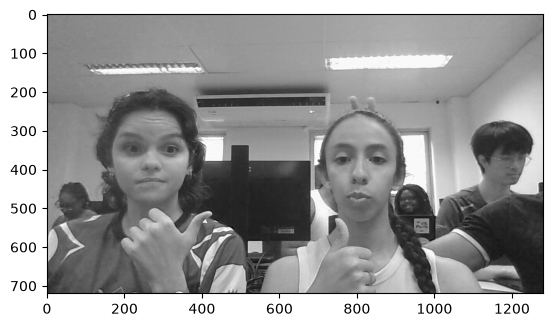

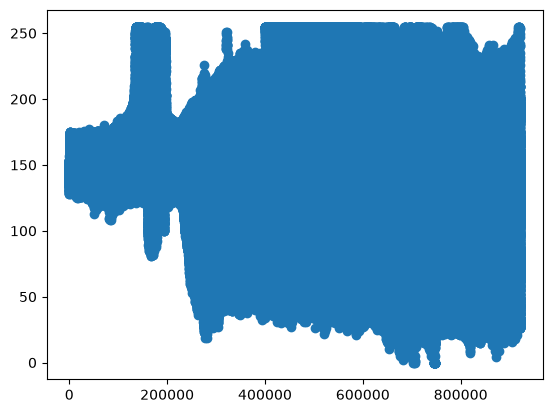

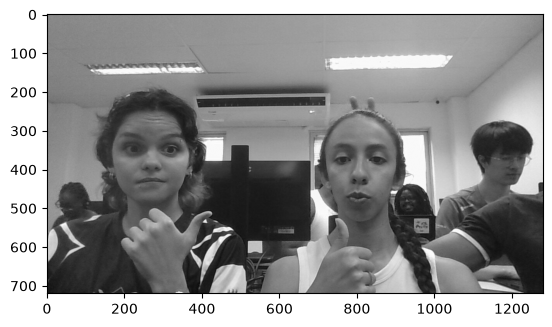

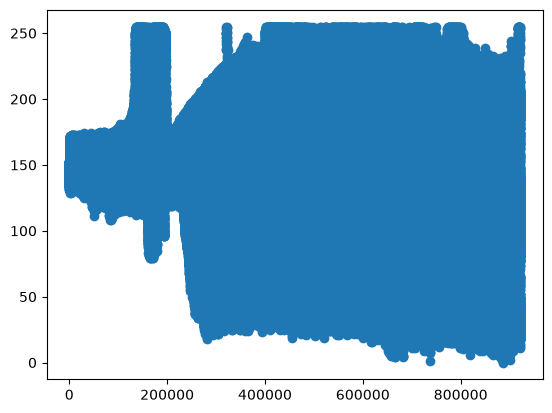

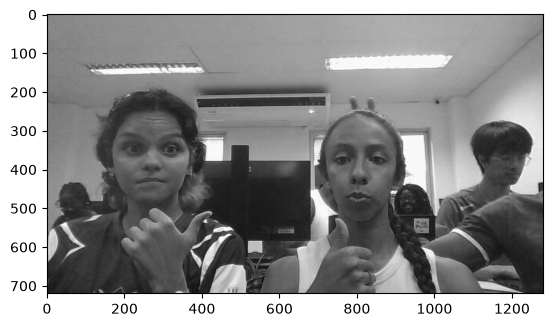

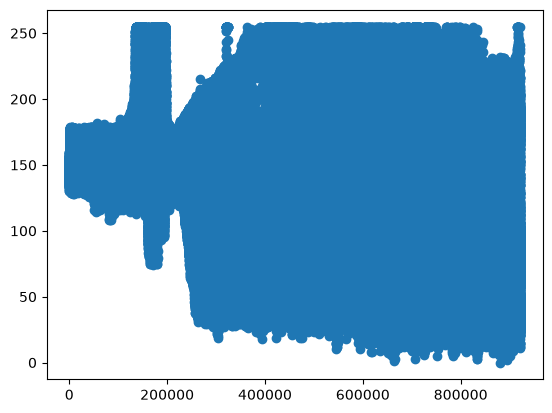

In [32]:
for cor in range(c):              # percorre os canais: 0 = R, 1 = G, 2 = B
    plano.append(img[:, :, cor])  # fatia todas as linhas e colunas de UM canal
                                  # resultado: matriz 2D de intensidades 0–255

    plt.imshow(plano[-1], cmap="gray")  # [-1] = último item adicionado à lista
    plt.show()                          # mostra o canal isolado em tons de cinza:
                                        # branco = intensidade alta naquele canal

    faixa.append(plano[-1].flatten())   # flatten(): transforma a matriz n x m em
                                        # um vetor de n*m elementos, lendo linha a linha
                                        # (é assim que o K-means enxerga: 1 pixel = 1 amostra)

    plt.scatter(np.arange(len(faixa[-1])), faixa[-1])
                                        # espalha os pontos: eixo X = índice do pixel,
                                        # eixo Y = intensidade daquele pixel
                                        # np.arange(N) gera [0, 1, 2, ..., N-1]
    plt.show()

In [33]:
# definir o número de clusters
K = 2                             # quantos agrupamentos de cor queremos encontrar

centroid = []                     # lista dos centroides iniciais
n_pixels = len(faixa[0])          # total de pixels da imagem (n * m)

for k in range(K):                # cria um centroide por cluster
    px = np.random.randint(0, n_pixels)  # sorteia o índice de um pixel qualquer

    v0 = faixa[0][px]             # valor R desse pixel
    v1 = faixa[1][px]             # valor G desse pixel
    v2 = faixa[2][px]             # valor B desse pixel

    centroid.append([v0, v1, v2]) # o centroide é um ponto no espaço RGB 3D
    print(f"Centroid {centroid[-1]}")

end = time.time()                 # marca o instante final
tempo_init = end - init           # duração total da inicialização, em segundos
print(f"Tempo de inicialização {tempo_init}")

Centroid [np.uint8(144), np.uint8(107), np.uint8(101)]
Centroid [np.uint8(163), np.uint8(133), np.uint8(109)]
Tempo de inicialização 7.321669340133667


In [34]:
init_agrupamento = time.time()
CLUSTER = [[] for _ in range (K)]
for px in range (n_pixels):
    v = [faixa[0][px], faixa[1][px], faixa[2][px]]
    d = []
    for k in range(K):
        d.append(np.linalg.norm(np.array(v) - np.array(centroid[k]))) # calcula a distância entre o vértice e o centroide

    cluster = np.argmin(d) # retorna o índice que possui o valor mínimo
    CLUSTER[cluster].append(px)

end_agrupamento = time.time()
tempo_agrupamento = end_agrupamento - init_agrupamento
print(f"Tempo do agrupamento para formar os cluters: {tempo_agrupamento}")
print(f"Tamanho cluster 1: {len(CLUSTER[0])}\nTamanho cluster 2: {len(CLUSTER[1])}")

Tempo do agrupamento para formar os cluters: 11.041041851043701
Tamanho cluster 1: 307361
Tamanho cluster 2: 614239


In [35]:
tic = time.time()
MAX_ITER = 1000
iteracao = 0
tempo_total_kmeans = 0

while iteracao < MAX_ITER:
    iteracao += 1
    tic = time.time()
    
    # Atribuir cada pixel ao cluster mais próximo
    CLUSTER = [[] for _ in range(K)]
    for px in range(n_pixels):
        v = np.array([faixa[0][px], faixa[1][px], faixa[2][px]])
        distancias = [np.linalg.norm(v - np.array(centroid[k])) for k in range(K)]
        cluster = np.argmin(distancias)
        CLUSTER[cluster].append(px)
    
    # Calcular novos centroides
    novo_centroid = []
    for k in range(K):
        if len(CLUSTER[k]) > 0:
            soma = np.zeros(3)
            for px in CLUSTER[k]:
                soma += np.array([faixa[0][px], faixa[1][px], faixa[2][px]])
            novo_centroid.append((soma / len(CLUSTER[k])).astype(int).tolist())
        else:
            novo_centroid.append(centroid[k])
    
    tempo_iter = time.time() - tic
    tempo_total_kmeans += tempo_iter
    print(f"Iterações: {iteracao}: centroides antigos = {centroid}")
    print(f"Iterações: {iteracao}: centroides novos = {novo_centroid}")
    print(f"Tempo parcial: {tempo_iter}s")
    
    # Verificar convergência: centroide antigo == novo centroide
    if np.array_equal(np.array(centroid), np.array(novo_centroid)):
        print(f"Convergiu, centróides corretos encontrados. Iterações: {iteracao}")
        print(f"Centroides antigo: {centroid}")
        print(f"Centroides final: {novo_centroid}")
        print(f"Tempo total K-means: {tempo_total_kmeans}s")
        break
    
    centroid = novo_centroid
else:
    print(f"Não convergiu após {MAX_ITER} iterações")
    print(f"Centroides finais: {novo_centroid}")
    print(f"Tempo total K-means: {tempo_total_kmeans}s")


Iterações: 1: centroides = [[np.uint8(144), np.uint8(107), np.uint8(101)], [np.uint8(163), np.uint8(133), np.uint8(109)]]
Iterações: 1: centroides = [[147, 139, 134], [121, 108, 106]]
Tempo parcial: 11.888648271560669s
Iterações: 2: centroides = [[147, 139, 134], [121, 108, 106]]
Iterações: 2: centroides = [[166, 161, 158], [85, 66, 63]]
Tempo parcial: 12.53385066986084s
Iterações: 3: centroides = [[166, 161, 158], [85, 66, 63]]
Iterações: 3: centroides = [[164, 159, 156], [80, 61, 59]]
Tempo parcial: 12.66176152229309s
Iterações: 4: centroides = [[164, 159, 156], [80, 61, 59]]
Iterações: 4: centroides = [[164, 158, 154], [79, 60, 58]]
Tempo parcial: 12.451703310012817s
Iterações: 5: centroides = [[164, 158, 154], [79, 60, 58]]
Iterações: 5: centroides = [[164, 158, 154], [78, 59, 58]]
Tempo parcial: 13.417679786682129s
Iterações: 6: centroides = [[164, 158, 154], [78, 59, 58]]
Iterações: 6: centroides = [[164, 158, 154], [78, 59, 58]]
Tempo parcial: 14.274779081344604s
Convergiu, cent